# BTCUSDT 15m — kiểm tra, làm sạch và phân tích dữ liệu

Notebook này phân tích `historical_data/BTCUSDT_15m_all.csv`. Quy trình ưu tiên khả năng kiểm toán: dữ liệu gốc không bị ghi đè, không tự nội suy OHLCV qua nến bị thiếu, và mọi dòng bị loại đều được thống kê.

## 1. Thiết lập

Nếu môi trường chưa có thư viện: `pip install pandas numpy matplotlib seaborn`.

In [1]:
from pathlib import Path
import sys
if Path(sys.prefix).name.lower() != '.venv':
    raise RuntimeError(
        'Đang chọn sai Jupyter kernel: ' + sys.executable + '\n'
        'Hãy chọn kernel BTC Pipeline (Python 3.10), trỏ tới .venv\\Scripts\\python.exe.'
    )
print('Python đang dùng:', sys.executable)
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'historical_data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / 'historical_data' / 'BTCUSDT_15m_all.csv'
OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'm15_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), f'Không tìm thấy {DATA_PATH}'
DATA_PATH

ModuleNotFoundError: No module named 'seaborn'

## 2. Đọc dữ liệu và kiểm tra ban đầu

In [ ]:
raw = pd.read_csv(DATA_PATH)
print(f'Số dòng: {len(raw):,} | Số cột: {raw.shape[1]} | Bộ nhớ: {raw.memory_usage(deep=True).sum()/1024**2:.2f} MB')
display(raw.head())
display(raw.tail())
display(raw.dtypes.rename('dtype').to_frame())

Số dòng: 235,056 | Số cột: 7 | Bộ nhớ: 29.14 MB


,open_time_ms,open_time_utc,open,high,low,close,volume
0,1577836800000,2020-01-01T00:00:00+00:00,"7,189.430000","7,190.520000","7,172.940000","7,176.260000","1,037.337000"
1,1577837700000,2020-01-01T00:15:00+00:00,"7,176.220000","7,179.410000","7,170.690000","7,172.360000",707.833000
2,1577838600000,2020-01-01T00:30:00+00:00,"7,172.790000","7,179.450000","7,170.610000","7,174.830000",325.246000
3,1577839500000,2020-01-01T00:45:00+00:00,"7,174.510000","7,179.360000","7,170.150000","7,171.550000",378.633000
4,1577840400000,2020-01-01T01:00:00+00:00,"7,171.430000","7,188.770000","7,171.100000","7,186.600000",555.389000


,open_time_ms,open_time_utc,open,high,low,close,volume
235051,1789382700000,2026-09-14T10:45:00+00:00,"77,915.100000","77,985.600000","77,856.800000","77,864.800000",654.490000
235052,1789383600000,2026-09-14T11:00:00+00:00,"77,864.800000","77,890.600000","77,674.100000","77,723.700000","1,378.274000"
235053,1789384500000,2026-09-14T11:15:00+00:00,"77,723.700000","77,886.800000","77,708.500000","77,873.000000",599.683000
235054,1789385400000,2026-09-14T11:30:00+00:00,"77,873.100000","77,892.600000","77,664.300000","77,793.000000","1,111.151000"
235055,1789386300000,2026-09-14T11:45:00+00:00,"77,793.000000","77,805.900000","77,653.200000","77,745.800000",590.640000


,dtype
open_time_ms,int64
open_time_utc,object
open,float64
high,float64
low,float64
close,float64
volume,float64


In [ ]:
EXPECTED_COLUMNS = ['open_time_ms', 'open_time_utc', 'open', 'high', 'low', 'close', 'volume']
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw.columns))
extra_columns = sorted(set(raw.columns) - set(EXPECTED_COLUMNS))
assert not missing_columns, f'Thiếu cột bắt buộc: {missing_columns}'
print('Cột ngoài schema:', extra_columns or 'Không có')

missing_report = pd.DataFrame({
    'missing_count': raw.isna().sum(),
    'missing_pct': raw.isna().mean().mul(100),
    'unique_count': raw.nunique(dropna=False),
})
display(missing_report)
display(raw[['open', 'high', 'low', 'close', 'volume']].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T)

Cột ngoài schema: Không có


,missing_count,missing_pct,unique_count
open_time_ms,0,0.000000,235056
open_time_utc,0,0.000000,235056
open,0,0.000000,210013
high,0,0.000000,191031
low,0,0.000000,191100
close,0,0.000000,210036
volume,0,0.000000,229931


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
open,"235,056.000000","49,809.522707","30,852.200620","3,757.750000","6,780.252000","9,188.347500","23,768.475000","43,712.345000","68,469.650000","108,417.075000","118,089.540000","125,986.100000"
high,"235,056.000000","49,904.460321","30,894.216487","4,155.210000","6,799.126500","9,201.587500","23,817.975000","43,810.300000","68,599.000000","108,553.650000","118,200.000000","126,208.500000"
low,"235,056.000000","49,712.544289","30,809.319683","3,621.810000","6,763.464000","9,178.000000","23,717.475000","43,627.460000","68,351.000000","108,270.025000","117,972.670000","125,583.000000"
close,"235,056.000000","49,809.821576","30,852.129611","3,761.100000","6,780.300000","9,188.357500","23,768.867500","43,712.755000","68,470.025000","108,417.050000","118,089.585000","125,986.000000"
volume,"235,056.000000","3,312.571066","4,621.196716",0.000000,238.447500,441.259000,"1,045.845500","1,943.807500","3,771.794000","10,485.488000","22,208.264500","171,631.082000"


## 3. Kiểm tra chất lượng

Các kiểm tra gồm timestamp, trùng lặp, khoảng nến thiếu, tính hữu hạn, giá/volume âm và quan hệ hình học OHLC.

In [ ]:
work = raw.copy()
numeric_cols = ['open_time_ms', 'open', 'high', 'low', 'close', 'volume']
for col in numeric_cols:
    work[col] = pd.to_numeric(work[col], errors='coerce')
work['timestamp'] = pd.to_datetime(work['open_time_ms'], unit='ms', utc=True, errors='coerce')
work['open_time_utc_parsed'] = pd.to_datetime(work['open_time_utc'], utc=True, errors='coerce')

duplicate_rows = work.duplicated().sum()
duplicate_timestamps = work.duplicated('open_time_ms', keep=False).sum()
timestamp_mismatch = (work['timestamp'] != work['open_time_utc_parsed']).fillna(True).sum()
invalid_numeric = work[numeric_cols].isna().any(axis=1) | ~np.isfinite(work[numeric_cols]).all(axis=1)
invalid_price_volume = (work[['open','high','low','close']] <= 0).any(axis=1) | (work['volume'] < 0)
invalid_ohlc = (
    (work['high'] < work[['open','close','low']].max(axis=1)) |
    (work['low'] > work[['open','close','high']].min(axis=1))
)
unaligned = work['open_time_ms'].mod(15 * 60 * 1000).ne(0)

ordered_unique_ms = work['open_time_ms'].dropna().drop_duplicates().sort_values()
gaps = ordered_unique_ms.diff().dropna()
gap_rows = gaps[gaps != 15 * 60 * 1000]
missing_candles_estimate = int(((gap_rows / (15 * 60 * 1000)) - 1).clip(lower=0).sum())

quality_report = {
    'source_rows': int(len(work)),
    'exact_duplicate_rows': int(duplicate_rows),
    'rows_in_duplicate_timestamps': int(duplicate_timestamps),
    'timestamp_parse_or_value_mismatches': int(timestamp_mismatch),
    'invalid_numeric_rows': int(invalid_numeric.sum()),
    'invalid_price_or_volume_rows': int(invalid_price_volume.sum()),
    'invalid_ohlc_rows': int(invalid_ohlc.sum()),
    'unaligned_15m_rows': int(unaligned.sum()),
    'non_15m_intervals': int(len(gap_rows)),
    'estimated_missing_candles': missing_candles_estimate,
    'first_timestamp': str(work['timestamp'].min()),
    'last_timestamp': str(work['timestamp'].max()),
}
display(pd.Series(quality_report, name='value').to_frame())
if len(gap_rows):
    display(pd.DataFrame({'gap_ms': gap_rows, 'gap_candles': gap_rows / (15*60*1000)}).head(20))

,value
source_rows,235056
exact_duplicate_rows,0
rows_in_duplicate_timestamps,0
timestamp_parse_or_value_mismatches,0
invalid_numeric_rows,0
invalid_price_or_volume_rows,0
invalid_ohlc_rows,0
unaligned_15m_rows,0
non_15m_intervals,0
estimated_missing_candles,0


## 4. Làm sạch

Chính sách: chuẩn hóa kiểu dữ liệu, sắp xếp thời gian, bỏ bản ghi trùng hoàn toàn, giữ bản ghi đầu tiên khi timestamp trùng, loại dòng không hợp lệ. Không forward-fill/interpolate OHLCV vì việc đó tạo ra nến chưa từng được giao dịch.

In [ ]:
bad_mask = invalid_numeric | invalid_price_volume | invalid_ohlc | unaligned | work['timestamp'].isna()
clean = (work.loc[~bad_mask]
         .drop_duplicates()
         .sort_values(['open_time_ms'])
         .drop_duplicates('open_time_ms', keep='first')
         .set_index('timestamp'))
clean = clean[['open_time_ms', 'open_time_utc', 'open', 'high', 'low', 'close', 'volume']]
clean.index.name = 'timestamp'

expected_index = pd.date_range(clean.index.min(), clean.index.max(), freq='15min', tz='UTC')
missing_timestamps = expected_index.difference(clean.index)
cleaning_summary = {
    **quality_report,
    'clean_rows': int(len(clean)),
    'removed_rows': int(len(raw) - len(clean)),
    'missing_timestamps_after_cleaning': int(len(missing_timestamps)),
}
display(pd.Series(cleaning_summary, name='value').to_frame())
display(clean.head())

,value
source_rows,235056
exact_duplicate_rows,0
rows_in_duplicate_timestamps,0
timestamp_parse_or_value_mismatches,0
invalid_numeric_rows,0
invalid_price_or_volume_rows,0
invalid_ohlc_rows,0
unaligned_15m_rows,0
non_15m_intervals,0
estimated_missing_candles,0


,open_time_ms,open_time_utc,open,high,low,close,volume
timestamp,,,,,,,
2020-01-01 00:00:00+00:00,1577836800000,2020-01-01T00:00:00+00:00,"7,189.430000","7,190.520000","7,172.940000","7,176.260000","1,037.337000"
2020-01-01 00:15:00+00:00,1577837700000,2020-01-01T00:15:00+00:00,"7,176.220000","7,179.410000","7,170.690000","7,172.360000",707.833000
2020-01-01 00:30:00+00:00,1577838600000,2020-01-01T00:30:00+00:00,"7,172.790000","7,179.450000","7,170.610000","7,174.830000",325.246000
2020-01-01 00:45:00+00:00,1577839500000,2020-01-01T00:45:00+00:00,"7,174.510000","7,179.360000","7,170.150000","7,171.550000",378.633000
2020-01-01 01:00:00+00:00,1577840400000,2020-01-01T01:00:00+00:00,"7,171.430000","7,188.770000","7,171.100000","7,186.600000",555.389000


## 5. Feature phục vụ phân tích

In [ ]:
df = clean.copy()
df['simple_return'] = df['close'].pct_change()
df['log_return'] = np.log(df['close']).diff()
df['candle_range_pct'] = (df['high'] - df['low']) / df['open']
df['body_pct'] = (df['close'] - df['open']) / df['open']
df['direction'] = np.select([df['close'] > df['open'], df['close'] < df['open']], ['up', 'down'], default='flat')
df['sma_20'] = df['close'].rolling(20, min_periods=20).mean()
df['sma_96'] = df['close'].rolling(96, min_periods=96).mean()
df['ema_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['volatility_96'] = df['log_return'].rolling(96, min_periods=48).std() * np.sqrt(96 * 365)
df['volume_z_96'] = (df['volume'] - df['volume'].rolling(96).mean()) / df['volume'].rolling(96).std()
delta = df['close'].diff()
gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
loss = -delta.clip(upper=0).ewm(alpha=1/14, adjust=False).mean()
df['rsi_14'] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
display(df.tail())

,open_time_ms,open_time_utc,open,high,low,close,volume,simple_return,log_return,candle_range_pct,body_pct,direction,sma_20,sma_96,ema_20,volatility_96,volume_z_96,rsi_14
timestamp,,,,,,,,,,,,,,,,,,
2026-09-14 10:45:00+00:00,1789382700000,2026-09-14T10:45:00+00:00,"77,915.100000","77,985.600000","77,856.800000","77,864.800000",654.490000,-0.000646,-0.000646,0.001653,-0.000646,down,"77,772.550000","77,259.276042","77,776.352718",0.290208,-0.478896,56.737652
2026-09-14 11:00:00+00:00,1789383600000,2026-09-14T11:00:00+00:00,"77,864.800000","77,890.600000","77,674.100000","77,723.700000","1,378.274000",-0.001812,-0.001814,0.002780,-0.001812,down,"77,771.430000","77,272.100000","77,771.338174",0.289794,0.284521,50.324364
2026-09-14 11:15:00+00:00,1789384500000,2026-09-14T11:15:00+00:00,"77,723.700000","77,886.800000","77,708.500000","77,873.000000",599.683000,0.001921,0.001919,0.002294,0.001921,up,"77,788.935000","77,285.001042","77,781.020252",0.289937,-0.533291,55.992654
2026-09-14 11:30:00+00:00,1789385400000,2026-09-14T11:30:00+00:00,"77,873.100000","77,892.600000","77,664.300000","77,793.000000","1,111.151000",-0.001027,-0.001028,0.002932,-0.001029,down,"77,793.640000","77,295.907292","77,782.161181",0.289751,-0.001777,52.533575
2026-09-14 11:45:00+00:00,1789386300000,2026-09-14T11:45:00+00:00,"77,793.000000","77,805.900000","77,653.200000","77,745.800000",590.640000,-0.000607,-0.000607,0.001963,-0.000607,down,"77,803.220000","77,306.250000","77,778.698211",0.290102,-0.552520,50.549391


## 6. Phân tích mô tả và trực quan

In [ ]:
analysis_summary = pd.Series({
    'start': df.index.min(), 'end': df.index.max(),
    'close_min': df['close'].min(), 'close_max': df['close'].max(),
    'total_return_pct': (df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100,
    'mean_15m_return_pct': df['simple_return'].mean() * 100,
    'return_std_15m_pct': df['simple_return'].std() * 100,
    'up_candle_pct': df['direction'].eq('up').mean() * 100,
    'down_candle_pct': df['direction'].eq('down').mean() * 100,
    'median_volume': df['volume'].median(),
}, name='value')
display(analysis_summary.to_frame())
display(df[['open','high','low','close','volume','simple_return','candle_range_pct','body_pct']].corr())

,value
start,2020-01-01 00:00:00+00:00
end,2026-09-14 11:45:00+00:00
close_min,"3,761.100000"
close_max,"125,986.000000"
total_return_pct,983.374906
mean_15m_return_pct,0.001580
return_std_15m_pct,0.336639
up_candle_pct,50.190167
down_candle_pct,49.735808
median_volume,"1,943.807500"


,open,high,low,close,volume,simple_return,candle_range_pct,body_pct
open,1.000000,0.999991,0.999989,0.999986,-0.201104,-0.004685,-0.116411,-0.004679
high,0.999991,1.000000,0.999981,0.999992,-0.199485,-0.002329,-0.114088,-0.002323
low,0.999989,0.999981,1.000000,0.999991,-0.203057,-0.002172,-0.119072,-0.002166
close,0.999986,0.999992,0.999991,1.000000,-0.201243,-0.000338,-0.116524,-0.000332
volume,-0.201104,-0.199485,-0.203057,-0.201243,1.000000,-0.032012,0.705065,-0.032170
simple_return,-0.004685,-0.002329,-0.002172,-0.000338,-0.032012,1.000000,-0.019558,0.999957
candle_range_pct,-0.116411,-0.114088,-0.119072,-0.116524,0.705065,-0.019558,1.000000,-0.019514
body_pct,-0.004679,-0.002323,-0.002166,-0.000332,-0.032170,0.999957,-0.019514,1.000000


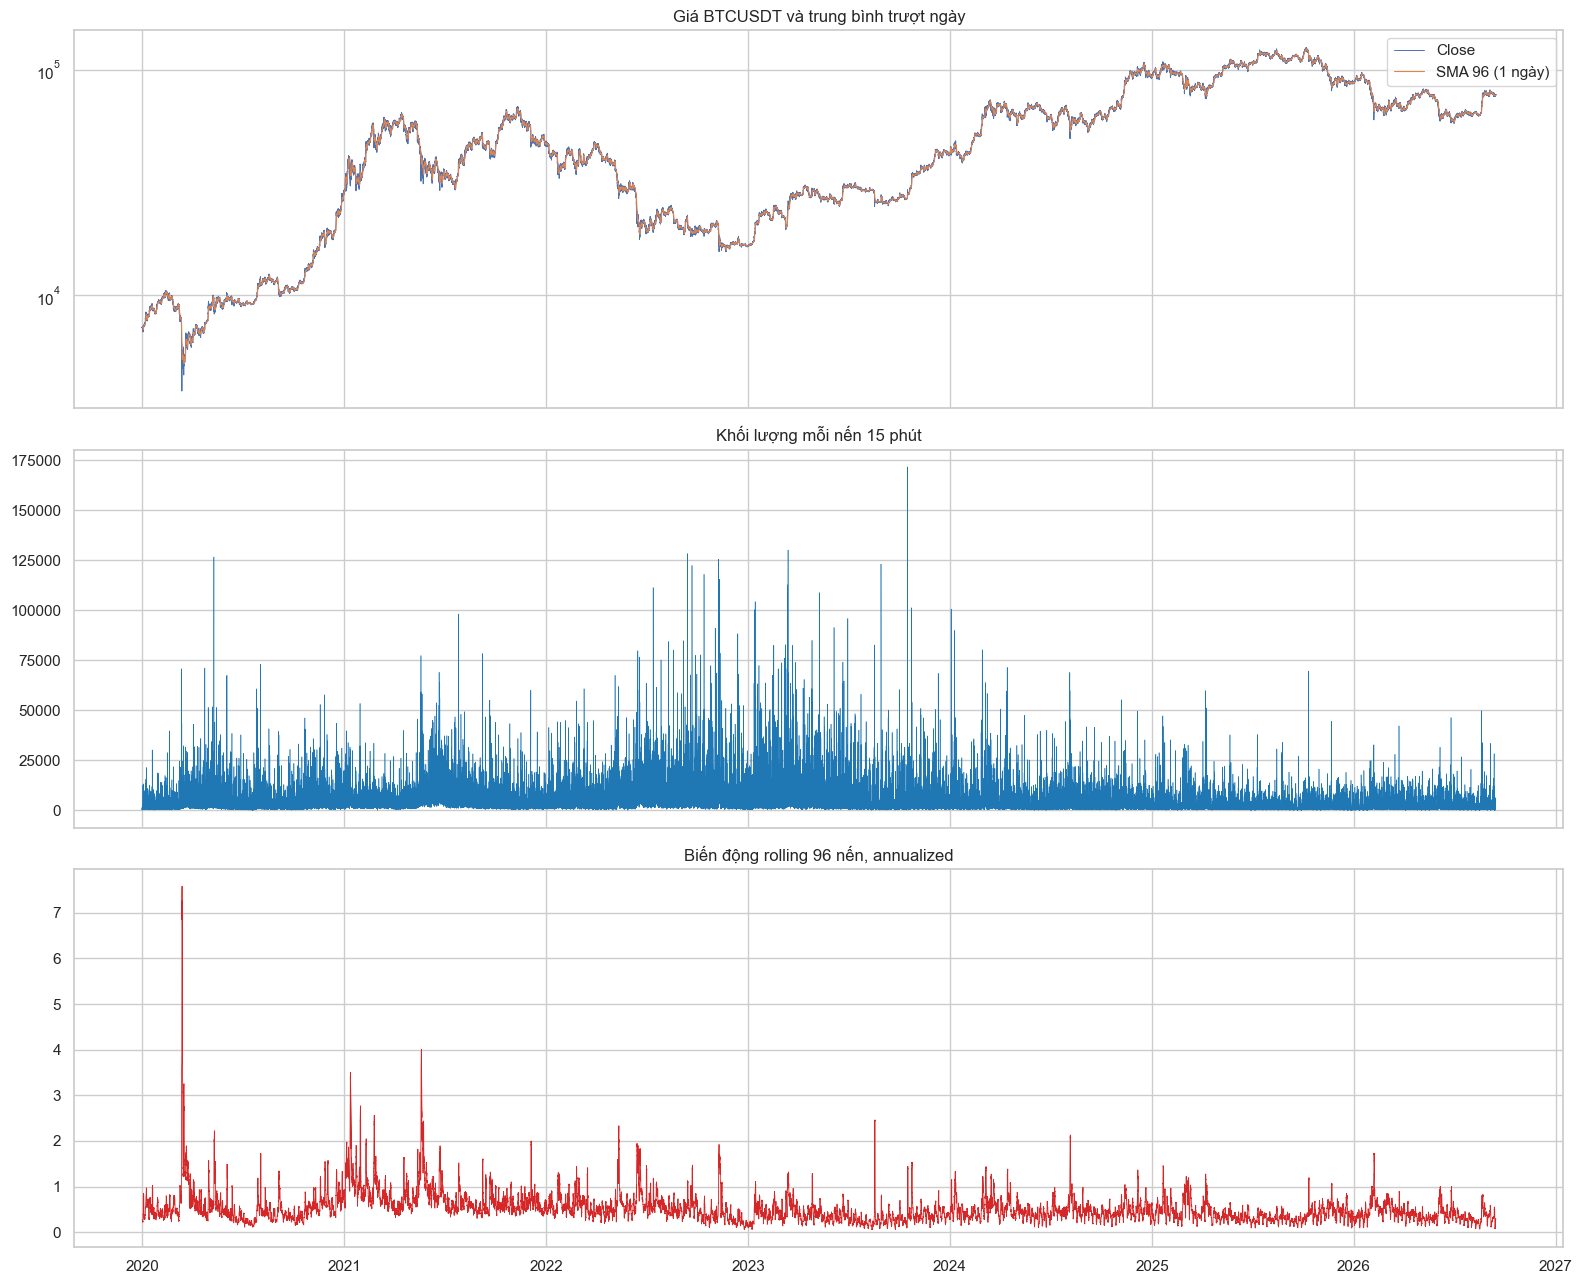

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
axes[0].plot(df.index, df['close'], lw=.7, label='Close')
axes[0].plot(df.index, df['sma_96'], lw=.8, label='SMA 96 (1 ngày)')
axes[0].set_title('Giá BTCUSDT và trung bình trượt ngày')
axes[0].set_yscale('log'); axes[0].legend()
axes[1].plot(df.index, df['volume'], lw=.4, color='tab:blue')
axes[1].set_title('Khối lượng mỗi nến 15 phút')
axes[2].plot(df.index, df['volatility_96'], lw=.6, color='tab:red')
axes[2].set_title('Biến động rolling 96 nến, annualized')
plt.tight_layout(); plt.show()

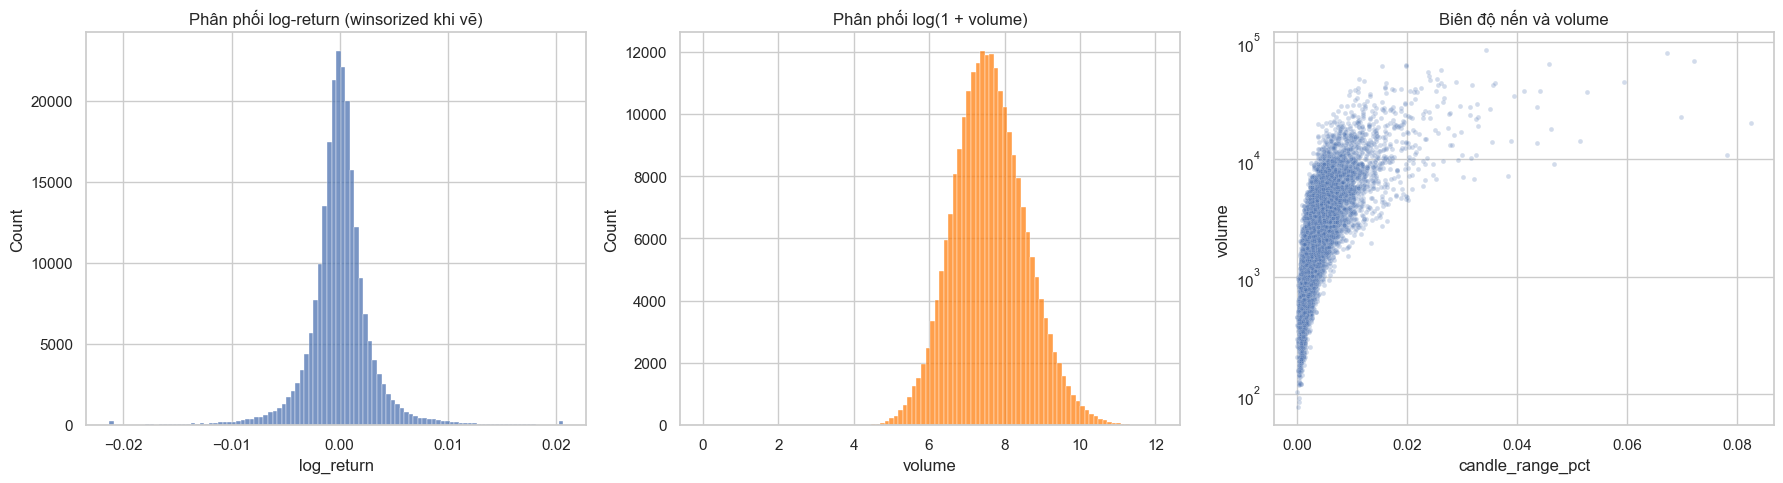

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['log_return'].dropna().clip(df['log_return'].quantile(.001), df['log_return'].quantile(.999)), bins=100, ax=axes[0])
axes[0].set_title('Phân phối log-return (winsorized khi vẽ)')
sns.histplot(np.log1p(df['volume']), bins=100, ax=axes[1], color='tab:orange')
axes[1].set_title('Phân phối log(1 + volume)')
sns.scatterplot(data=df.sample(min(10000, len(df)), random_state=42), x='candle_range_pct', y='volume', alpha=.25, s=12, ax=axes[2])
axes[2].set_yscale('log'); axes[2].set_title('Biên độ nến và volume')
plt.tight_layout(); plt.show()

## 7. Mùa vụ theo thời gian (UTC)

,mean_abs_return,median_volume,mean_range
hour,,,
0,0.002257,"2,037.993000",0.004607
1,0.002016,"1,749.311000",0.004144
2,0.001858,"1,597.546000",0.003797
3,0.001664,"1,460.196500",0.003491
4,0.001590,"1,429.157500",0.003354
5,0.001591,"1,417.948500",0.003307
6,0.001642,"1,532.033500",0.003387
7,0.001679,"1,689.745500",0.003485
8,0.001824,"1,935.368000",0.003817


,mean_abs_return,median_volume
weekday,,
Monday,0.002194,"2,262.912000"
Tuesday,0.002146,"2,266.202500"
Wednesday,0.002148,"2,255.017500"
Thursday,0.002153,"2,251.781500"
Friday,0.002152,"2,193.993500"
Saturday,0.001457,"1,202.526000"
Sunday,0.001597,"1,386.472500"


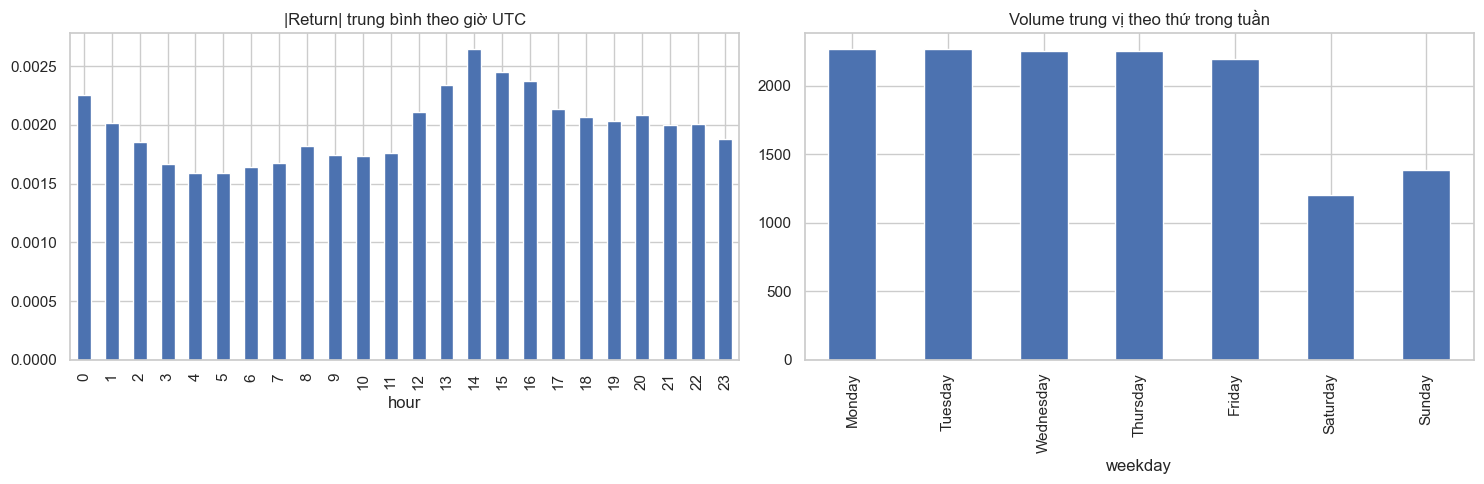

In [ ]:
seasonal = df.assign(hour=df.index.hour, weekday=df.index.day_name())
hourly = seasonal.groupby('hour').agg(
    mean_abs_return=('log_return', lambda x: x.abs().mean()),
    median_volume=('volume', 'median'),
    mean_range=('candle_range_pct', 'mean'))
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday = seasonal.groupby('weekday').agg(
    mean_abs_return=('log_return', lambda x: x.abs().mean()),
    median_volume=('volume', 'median')).reindex(weekday_order)
display(hourly); display(weekday)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hourly['mean_abs_return'].plot(kind='bar', ax=axes[0], title='|Return| trung bình theo giờ UTC')
weekday['median_volume'].plot(kind='bar', ax=axes[1], title='Volume trung vị theo thứ trong tuần')
plt.tight_layout(); plt.show()

## 8. Quan sát cực trị và tổng hợp theo tháng

In [ ]:
display(df.nlargest(10, 'log_return')[['open','high','low','close','volume','log_return']])
display(df.nsmallest(10, 'log_return')[['open','high','low','close','volume','log_return']])
display(df.nlargest(10, 'volume')[['open','high','low','close','volume','log_return']])

monthly = df.resample('ME').agg(
    open=('open','first'), high=('high','max'), low=('low','min'), close=('close','last'),
    volume=('volume','sum'), candles=('close','count'))
monthly['return_pct'] = monthly['close'].pct_change() * 100
monthly['realized_vol'] = df['log_return'].resample('ME').std() * np.sqrt(96 * 365)
display(monthly.tail(24))

,open,high,low,close,volume,log_return
timestamp,,,,,,
2020-03-13 02:30:00+00:00,"4,154.470000","5,211.000000","4,100.000000","5,138.560000","30,845.934000",0.212588
2020-03-13 02:15:00+00:00,"3,757.750000","4,155.210000","3,621.810000","4,154.470000","21,113.925000",0.099473
2021-01-29 08:45:00+00:00,"33,362.810000","36,929.000000","33,358.500000","36,397.810000","53,406.863000",0.087067
2020-03-13 03:15:00+00:00,"4,948.000000","5,529.970000","4,948.000000","5,348.340000","19,617.221000",0.077803
2021-05-19 13:30:00+00:00,"33,258.910000","36,580.000000","33,088.460000","35,900.000000","7,631.048000",0.076415
2021-02-08 12:45:00+00:00,"40,560.800000","43,880.000000","40,542.000000","43,506.100000","33,789.606000",0.070099
2021-05-19 14:45:00+00:00,"35,234.800000","37,618.000000","35,167.260000","37,435.850000","23,002.558000",0.060708
2021-01-11 14:15:00+00:00,"31,167.070000","33,445.550000","31,146.150000","33,100.000000","27,032.550000",0.060171
2020-03-13 05:00:00+00:00,"4,719.250000","5,079.370000","4,702.650000","5,004.950000","16,108.725000",0.058811


,open,high,low,close,volume,log_return
timestamp,,,,,,
2020-03-12 10:30:00+00:00,"7,211.940000","7,211.950000","6,270.000000","6,304.450000","70,749.813000",-0.134484
2023-08-17 21:30:00+00:00,"27,660.000000","27,704.300000","24,581.000000","24,804.100000","82,629.801000",-0.108978
2020-03-13 01:45:00+00:00,"4,489.640000","4,494.320000","3,950.000000","4,062.890000","22,589.980000",-0.100920
2020-05-10 00:15:00+00:00,"9,345.600000","9,349.990000","7,940.000000","8,506.180000","126,602.642000",-0.094108
2020-03-12 23:15:00+00:00,"5,516.840000","5,617.050000","4,578.030000","5,038.520000","43,580.136000",-0.090336
2021-05-19 13:00:00+00:00,"35,060.390000","35,140.200000","28,688.000000","32,133.800000","38,881.477000",-0.087164
2020-03-13 02:45:00+00:00,"5,138.560000","5,228.230000","4,556.250000","4,723.950000","19,286.715000",-0.084128
2020-08-02 04:30:00+00:00,"11,947.690000","11,993.000000","10,490.000000","11,027.880000","73,011.116000",-0.080110
2020-03-13 02:00:00+00:00,"4,062.950000","4,242.000000","3,725.510000","3,761.100000","21,417.969000",-0.077183


,open,high,low,close,volume,log_return
timestamp,,,,,,
2023-10-16 13:30:00+00:00,"29,470.400000","30,720.000000","27,950.000000","28,232.100000","171,631.082000",-0.042801
2023-03-14 12:30:00+00:00,"24,641.800000","25,650.000000","24,405.000000","25,522.600000","130,088.675000",0.035080
2022-09-13 12:30:00+00:00,"22,707.100000","22,850.000000","21,615.000000","21,665.300000","128,323.789000",-0.047014
2020-05-10 00:15:00+00:00,"9,345.600000","9,349.990000","7,940.000000","8,506.180000","126,602.642000",-0.094108
2022-11-08 19:30:00+00:00,"17,679.000000","18,390.000000","16,830.000000","18,161.900000","125,523.668000",0.026948
2023-08-29 14:15:00+00:00,"26,179.800000","27,222.000000","26,169.300000","26,936.300000","123,083.036000",0.028487
2022-09-21 18:00:00+00:00,"19,839.400000","20,154.100000","18,343.000000","18,859.800000","122,367.123000",-0.050990
2022-10-13 12:30:00+00:00,"18,802.500000","18,802.500000","17,917.800000","18,319.500000","117,958.449000",-0.020557
2022-11-10 13:30:00+00:00,"16,625.900000","17,739.000000","16,563.300000","17,349.100000","115,519.681000",0.042579


,open,high,low,close,volume,candles,return_pct,realized_vol
timestamp,,,,,,,,
2024-10-31 00:00:00+00:00,"63,309.000000","73,660.000000","58,900.000000","70,321.900000","7,195,878.976000",2976,11.077081,0.398565
2024-11-30 00:00:00+00:00,"70,321.900000","99,660.000000","66,810.000000","96,475.100000","8,938,205.818000",2880,37.190690,0.548720
2024-12-31 00:00:00+00:00,"96,475.200000","108,366.800000","90,200.000000","93,548.900000","6,822,690.657000",2976,-3.033114,0.560012
2025-01-31 00:00:00+00:00,"93,548.800000","110,000.000000","88,909.000000","102,379.700000","6,301,585.790000",2976,9.439769,0.552423
2025-02-28 00:00:00+00:00,"102,379.800000","102,734.900000","78,200.200000","84,299.600000","5,450,459.865000",2688,-17.659849,0.505890
2025-03-31 00:00:00+00:00,"84,299.600000","94,971.000000","76,560.000000","82,517.500000","7,147,828.164000",2976,-2.114008,0.592689
2025-04-30 00:00:00+00:00,"82,517.500000","95,769.600000","74,457.000000","94,125.100000","6,879,530.497000",2880,14.066834,0.525545
2025-05-31 00:00:00+00:00,"94,125.200000","111,959.500000","93,327.000000","104,544.700000","5,650,909.877000",2976,11.069948,0.360682
2025-06-30 00:00:00+00:00,"104,544.600000","110,653.600000","98,115.400000","107,087.400000","4,489,492.347000",2880,2.432165,0.334930


## 9. Xuất dữ liệu sạch và báo cáo

Cell này ghi file mới vào `artifacts/m15_analysis`; không thay đổi CSV gốc.

In [ ]:
clean_path = OUTPUT_DIR / 'BTCUSDT_15m_clean.csv'
report_path = OUTPUT_DIR / 'quality_report.json'
monthly_path = OUTPUT_DIR / 'monthly_summary.csv'

clean.reset_index(drop=True).to_csv(clean_path, index=False)
monthly.to_csv(monthly_path, index_label='month_utc')
report_path.write_text(json.dumps(cleaning_summary, indent=2, default=str), encoding='utf-8')
print(clean_path)
print(report_path)
print(monthly_path)

C:\Users\thanh\BTC_PIPELINE\artifacts\m15_analysis\BTCUSDT_15m_clean.csv
C:\Users\thanh\BTC_PIPELINE\artifacts\m15_analysis\quality_report.json
C:\Users\thanh\BTC_PIPELINE\artifacts\m15_analysis\monthly_summary.csv


## Kết quả kiểm tra tại thời điểm tạo notebook

Với file hiện tại: **235.056 nến**, từ **2020-01-01 00:00 UTC** đến **2026-09-14 11:45 UTC**. Không phát hiện dòng trùng, timestamp trùng, gap 15 phút, hay dòng OHLCV không hợp lệ. Close thấp nhất là **3.761,1**, cao nhất **125.986 USDT**; lợi suất giá đóng cửa toàn kỳ khoảng **983,37%**. Các cell bên trên sẽ tính lại toàn bộ con số khi dữ liệu nguồn được cập nhật.

## Ghi chú diễn giải

- Return 15 phút thường có đuôi dày; không nên mặc định phân phối chuẩn.
- Volume và volatility thường không dừng theo toàn bộ lịch sử; nên chia train/validation/test theo thời gian.
- Khoảng nến thiếu được báo cáo nhưng không nội suy. Khi huấn luyện mô hình sequence, cần cắt chuỗi tại gap để không coi hai nến cách xa là liên tiếp.
- Mọi timestamp và phân tích mùa vụ trong notebook đều dùng UTC.